ENSO shape: (44, 12)


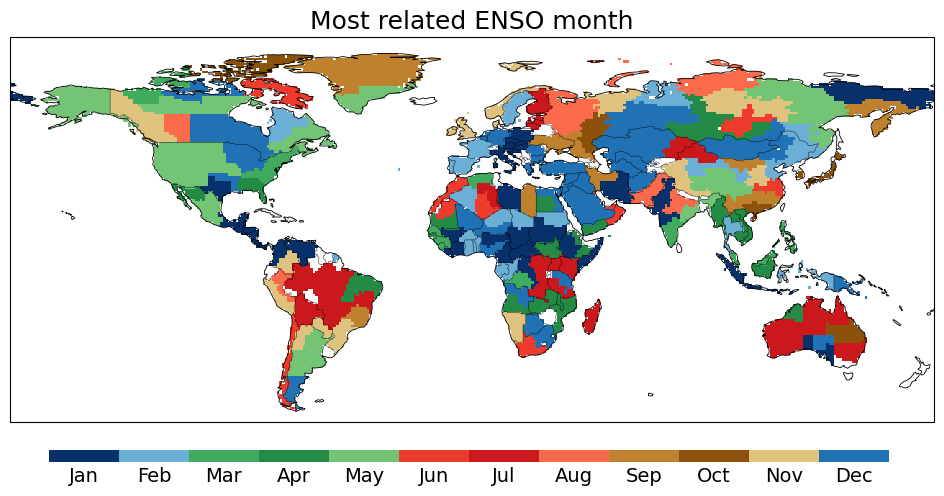

✅ Finished.


In [32]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# =========================================================
# 1. 数据加载
# =========================================================

obs_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/hottestmonth/Berkeley_hottest_month_by_region_revised_by_ERA5.nc"
)

mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

nino_ds = xr.open_dataset("nino34_monthly_1980_2024.nc")

region_mask = mask_ds["region_id"]

obs_data = obs_ds["t2m_hottest"].sel(year=slice(1981, 2024))
nino = nino_ds["nino34"]

months = np.arange(1, 13)

# =========================================================
# 2. 构造 (year, month) ENSO index
# =========================================================

nino_ym = (
    nino
    .assign_coords(
        year=("time", nino.time.dt.year.data),
        month=("time", nino.time.dt.month.data)
    )
    .set_index(time=["year", "month"])
    .unstack("time")
)

nino_ym = nino_ym.sel(year=slice(1981, 2024))

print("ENSO shape:", nino_ym.shape)

# =========================================================
# 3. 逐区域寻找最佳相关月份
# =========================================================

regions = obs_data.region_id.values

best_month = np.full(len(regions), np.nan)

common_years = np.intersect1d(
    obs_data.year.values,
    nino_ym.year.values
)

obs_sel = obs_data.sel(year=common_years)
nino_sel = nino_ym.sel(year=common_years)

for j, rid in enumerate(regions):

    y = obs_sel.sel(region_id=rid).values

    corr_list = []

    for m in months:

        x = nino_sel.sel(month=m).values

        valid = (~np.isnan(x)) & (~np.isnan(y))

        if valid.sum() < 10:
            corr = np.nan
        else:
            corr, _ = pearsonr(x[valid], y[valid])

        corr_list.append(corr)

    corr_arr = np.array(corr_list)

    if np.all(np.isnan(corr_arr)):
        continue

    idx = np.nanargmax(np.abs(corr_arr))

    best_month[j] = months[idx]

# =========================================================
# 4. 映射回经纬度网格
# =========================================================

best_month_da = xr.DataArray(
    best_month,
    coords={"region_id": regions},
    dims=["region_id"]
)

month_map = xr.full_like(
    region_mask,
    np.nan,
    dtype=float
)

for rid in regions:

    month_map = xr.where(
        region_mask == rid,
        best_month_da.sel(region_id=rid),
        month_map
    )

# =========================================================
# 5. 绘图
# =========================================================

from matplotlib.colors import ListedColormap

colors = [
    "#08306b",  # 1 深蓝
    "#6baed6",  # 2

    # 🌱 春（3,4,5）绿色系
    "#41ab5d",  # 3
    "#238b45",  # 4 深绿
    "#74c476",  # 5

    # ☀️ 夏（6,7,8）红色系
    
    "#ef3b2c",  # 6
    "#cb181d",  # 7 深红
    "#fb6a4a",  # 8

    # 🍂 秋（9,10,11）棕色系

    "#bf812d",  # 9
    "#8c510a",  # 10 深棕
    "#dfc27d",   # 11 浅棕
    # ❄️ 冬（12,1,2）蓝色系
    "#2171b5",  # 12
]

cmap = ListedColormap(colors)

fig = plt.figure(figsize=(12, 5))

ax = plt.axes(projection=ccrs.PlateCarree())

levels = np.arange(0.5, 13.5, 1)

im = month_map.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    levels=levels,
    add_colorbar=False,
    extend="neither"
)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

ax.set_extent([-180, 180, -60, 90])

ax.set_title(
    "Most related ENSO month",
    fontsize=18
)

# =========================================================
# ✔ colorbar (add_axes 版本)
# =========================================================

cbar_ax = fig.add_axes([0.16, 0.03, 0.7, 0.025])  
# [left, bottom, width, height]

cbar = plt.colorbar(
    im,
    cax=cbar_ax,
    orientation="horizontal"
)

#cbar.set_label("Month")

cbar.set_ticks(np.arange(1, 13))
cbar.set_ticklabels(
    ["Jan","Feb","Mar","Apr","May","Jun",
     "Jul","Aug","Sep","Oct","Nov","Dec"],
    fontsize=14
)

# 去掉刻度线（关键）
cbar.minorticks_off()
cbar.ax.tick_params(which='both', length=0)
cbar.outline.set_visible(False)

plt.savefig(
    "ENSO_best_month_map.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Finished.")